![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

## Quiver Insider Trading Research

This notebook studies whether insider dollar volume helps explain future returns

In [1]:
qb = QuantBook()
# Anchor the research clock to the start of 2026 for a reproducible history window.
qb.set_start_date(2026, 1, 1)
# Daily bars will have an end_time that matches the following midnight.
qb.settings.daily_precise_end_time = False

### Build an Insider Trading Universe

Select the 10 assets with the largest insider-trading dollar volume each day, then inspect the returned universe history.

In [2]:
def select_assets(data: List[QuiverInsiderTradingUniverse]) -> List[Symbol]:
    # Aggregate insider dollar volume per ticker and keep the 10 largest.
    dollar_volume: dict[Symbol, float] = {}
    for d in data:
        if not d.price_per_share:
            continue
        dollar_volume[d.symbol] = dollar_volume.get(d.symbol, 0) + (d.shares or 0) * d.price_per_share
    return [s for s, _ in sorted(dollar_volume.items(), key=lambda kv: kv[1])[-10:]]

# Add the Quiver Insider Trading universe.
universe = qb.add_universe(QuiverInsiderTradingUniverse, select_assets)
# Request universe history of the last 120 days.
universe_history = qb.universe_history(universe, qb.time - timedelta(120), qb.time - timedelta(1), flatten=True)
# Print the returned shape and columns.
print(f"Shape: {universe_history.shape}")
print(f"Columns: {list(universe_history.columns)}")
universe_history.head()

Shape: (1170, 15)
Columns: ['acquireddisposedcode', 'date', 'directorindirectownership', 'filedate', 'isdirector', 'isofficer', 'istenpercentowner', 'name', 'officertitle', 'pricepershare', 'shares', 'sharesownedfollowing', 'transactioncode', 'value', 'isother']


acquireddisposedcode       date  \
time       symbol                                              
2025-09-04 ABNB XK8H247DY6W5             Disposed 2025-09-02   
           ALAB YGY3PXP9GIUD             Disposed 2025-09-02   
           APG XE2XH2WEQFS5              Disposed 2025-09-02   
           CRWV YR5DGT57ZXPH             Disposed 2025-09-02   
           DASH XK7HM0U7VFQD             Acquired 2025-09-02   

                             directorindirectownership   filedate isdirector  \
time       symbol                                                              
2025-09-04 ABNB XK8H247DY6W5                  Indirect 2025-09-03       True   
           ALAB YGY3PXP9GIUD                    Direct 2025-09-03       True   
           APG XE2XH2WEQFS5                   Indirect 2025-09-03       True   
           CRWV YR5DGT57ZXPH                    Direct 2025-09-03      False   
           DASH XK7HM0U7VFQD                  Indirect 2025-09-03       True   

                             isofficer istenpercentowner               name  \
time       symbol                                                             
2025-09-04 ABNB XK8H247DY6W5     False              True      Gebbia Joseph   
           ALAB YGY3PXP9GIUD      True             False    Gajendra Sanjay   
           APG XE2XH2WEQFS5      False              True  FRANKLIN MARTIN E   
           CRWV YR5DGT57ZXPH      True             False      McBee Brannin   
           DASH XK7HM0U7VFQD     False             False          Fang Andy   

                                           officertitle  pricepershare  \
time       symbol                                                        
2025-09-04 ABNB XK8H247DY6W5                                  126.7568   
           ALAB YGY3PXP9GIUD          President and COO         0.0000   
           APG XE2XH2WEQFS5                                    34.6400   
           CRWV YR5DGT57ZXPH  Chief Development Officer        91.3532   
           DASH XK7HM0U7VFQD                                    0.0000   

                                 shares  sharesownedfollowing transactioncode  \
time       symbol                                                               
2025-09-04 ABNB XK8H247DY6W5    50167.0             1597848.0            Sale   
           ALAB YGY3PXP9GIUD   480668.0             1690209.0            Gift   
           APG XE2XH2WEQFS5   1200000.0            19868790.0            Sale   
           CRWV YR5DGT57ZXPH    28735.0              343230.0            Sale   
           DASH XK7HM0U7VFQD    30000.0               30000.0           Other   

                                 value isother  
time       symbol                               
2025-09-04 ABNB XK8H247DY6W5  126.7568     NaN  
           ALAB YGY3PXP9GIUD    0.0000     NaN  
           APG XE2XH2WEQFS5    34.6400     NaN  
           CRWV YR5DGT57ZXPH   91.3532     NaN  
           DASH XK7HM0U7VFQD    0.0000     NaN

### Universe Diagnostics

Derive each trade's dollar volume, then inspect its distribution and visualize how the unique asset footprint expands chronologically.

Universe days: 119
Mean basket size per day: 9.8

count               1170.000
mean        111908606995.679
std        3057678599160.407
min                    0.000
25%                55142.400
50%              1345218.290
75%              8366895.905
max      100000000000000.000
Name: dollarvolume, dtype: object


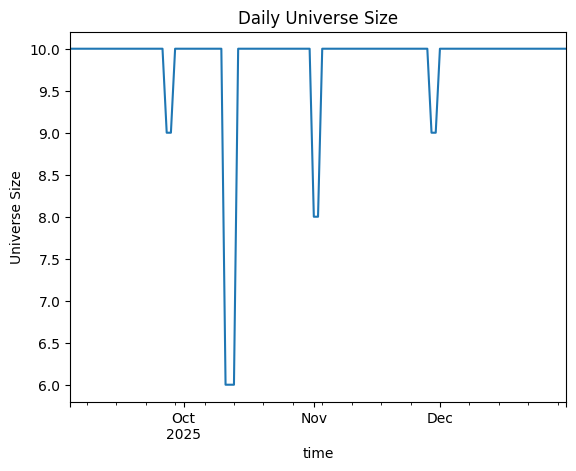

In [3]:
# Derive each insider trade's dollar volume from shares and price per share.
universe_history['dollarvolume'] = universe_history['shares'].fillna(0) * universe_history['pricepershare'].fillna(0)
# Count selected assets by day.
universe_size = universe_history.groupby(level=[0, 1]).count().dollarvolume.groupby(level=0).count()
print(f"Universe days: {len(universe_size)}")
# Store the selected symbol list.
unique_assets = list(universe_history.index.levels[1].unique())
print(f"Mean basket size per day: {universe_size.mean():.1f}")
print('')
print(universe_history.dollarvolume.describe().map('{:0.3f}'.format))
universe_size.plot(title='Daily Universe Size', ylabel='Universe Size');

### Daily Universe Prices

Fetch daily price history for every symbol that appears in the universe.

In [4]:
# Extract unique assets
symbols = list(universe_history.index.get_level_values(1).unique())
# Fetch daily historical price metrics using the earliest timestamp available in the index.
history = qb.history(symbols, universe_history.index[0][0] - timedelta(1), qb.time, Resolution.DAILY)
history

close    high      low    open     volume
symbol            time                                                   
ABNB XK8H247DY6W5 2025-09-04  124.900  127.75  124.465  127.42  6080811.0
                  2025-09-05  125.370  125.65  123.180  124.65  5994862.0
                  2025-09-06  123.810  127.37  122.820  125.37  3961612.0
                  2025-09-09  124.620  126.09  123.050  124.37  4532379.0
                  2025-09-10  123.810  124.78  123.600  124.12  3475032.0
...                               ...     ...      ...     ...        ...
MDLN YYDBHHPS742T 2025-12-25   44.280   45.01   43.550   43.95  4363660.0
                  2025-12-27   44.085   45.45   43.610   44.50  8118252.0
                  2025-12-30   42.090   43.80   41.735   43.57  5517778.0
                  2025-12-31   41.820   43.25   41.620   42.05  4102917.0
                  2026-01-01   42.000   43.07   41.210   41.94  5587994.0

[39076 rows x 5 columns]

### Align Insider Volume And Returns

Build a joined table of insider dollar volume and future returns.

In [ ]:
dataset = (
    universe_history.groupby(level=[0, 1]).agg(dollarvolume=('dollarvolume', 'sum')).rename_axis(['time', 'symbol'])
    .join(history.open.unstack('symbol').sort_index().pct_change(2, fill_method=None).shift(-2).stack().rename('futurereturn').rename_axis(['time','symbol']), how='inner')
)
dataset.head()

dollarvolume  futurereturn
time       symbol                                       
2025-09-04 ABNB XK8H247DY6W5  6.359008e+06     -0.016089
           ALAB YGY3PXP9GIUD  0.000000e+00      0.111487
           APG XE2XH2WEQFS5   4.156800e+07      0.012349
           CRWV YR5DGT57ZXPH  2.625034e+06     -0.038096
           DASH XK7HM0U7VFQD  0.000000e+00      0.028356

### Analyze Relationships Between Factor and Future Returns

Drop the 1% outliers on each side of the factor and fit a line of best fit, then create a box plot of dollar-volume quantile buckets compared to future returns.

Factor: dollarvolume
Observations: 785
Mean future return: 0.15%
Alpha: 0.14%
Beta: 0.00%
R-squared: 0.00%


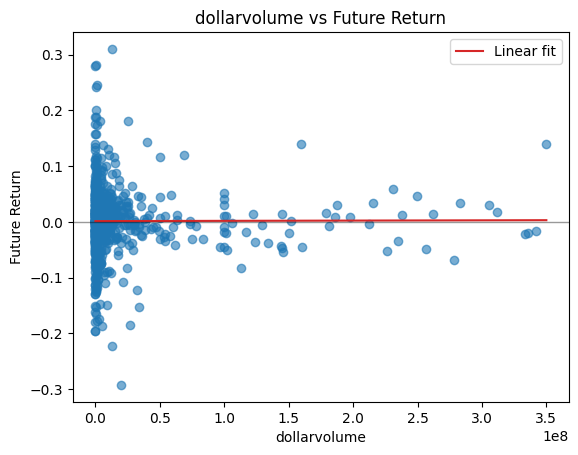

In [8]:
y = dataset['futurereturn']
factor = 'dollarvolume'
# Assign the factor values.
x = dataset[factor]
# Drop the 1% outliers on each side of the factor.
lower, upper = x.quantile([0.01, 0.99])
mask = x.between(lower, upper)
x, y = x[mask], y[mask]
# Fit a simple linear model.
slope, intercept = np.polyfit(x, y, 1)
r_squared = x.corr(y) ** 2
# Print the linear model statistics.
print(f"Factor: {factor}")
print(f"Observations: {len(x)}")
print(f"Mean future return: {y.mean():.2%}")
print(f"Alpha: {intercept:.2%}")
print(f"Beta: {slope:.2%}")
print(f"R-squared: {r_squared:.2%}")
# Plot the factor values against future returns.
plt.scatter(x, y, alpha=0.6)
plt.plot(x.sort_values(), intercept + slope * x.sort_values(), color='tab:red', label='Linear fit')
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'{factor} vs Future Return')
plt.xlabel(factor)
plt.ylabel('Future Return')
plt.legend()
plt.show()

Factor: dollarvolume


,bucket,mean_factor,min_future_return,max_future_return,mean_future_return,std_future_return,observations
0,"(-0.001, 7139.512]",201.625,-19.53%,27.92%,0.13%,6.17%,157
1,"(7139.512, 498193.404]",191401.914,-19.58%,28.23%,0.09%,6.31%,157
2,"(498193.404, 3172799.648]",1649172.888,-17.73%,24.59%,0.10%,5.59%,157
3,"(3172799.648, 14003365.265]",7109155.786,-22.35%,31.05%,0.41%,6.04%,157
4,"(14003365.265, 349999986.0]",77815736.927,-29.27%,18.14%,0.01%,5.42%,157


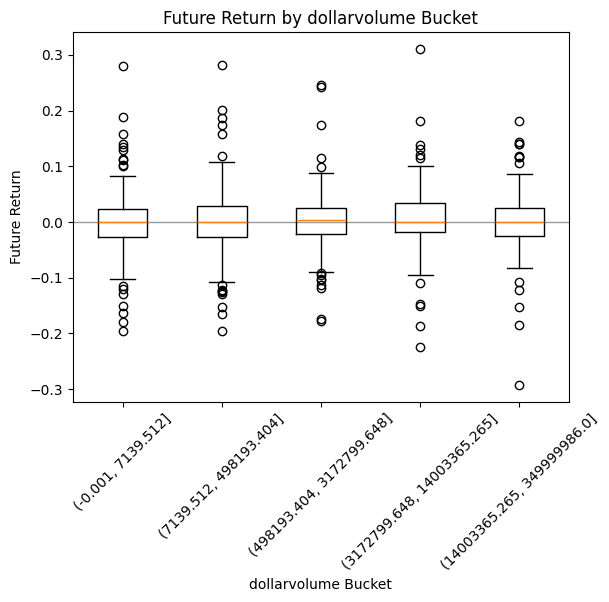

In [9]:
# Split factor values into quantile buckets.
buckets = pd.qcut(x, q=5, duplicates='drop')
# Summarize each bucket with distribution statistics.
summary = dataset.assign(bucket=buckets).groupby('bucket', observed=True).agg(
    mean_factor=(factor, 'mean'),
    min_future_return=('futurereturn', 'min'),
    max_future_return=('futurereturn', 'max'),
    mean_future_return=('futurereturn', 'mean'),
    std_future_return=('futurereturn', 'std'),
    observations=('futurereturn', 'size')
).reset_index()
summary['bucket'] = summary['bucket'].astype(str)
# Display the bucket summary.
print(f"Factor: {factor}")
display(summary.style.format({
    'mean_factor': '{:.3f}',
    'min_future_return': '{:.2%}',
    'max_future_return': '{:.2%}',
    'mean_future_return': '{:.2%}',
    'std_future_return': '{:.2%}'
}))
# Plot the return distribution for each bucket.
groups = [y[buckets == b].values for b in buckets.cat.categories]
plt.boxplot(groups, labels=[str(b) for b in buckets.cat.categories])
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'Future Return by {factor} Bucket')
plt.xlabel(f'{factor} Bucket')
plt.ylabel('Future Return')
plt.xticks(rotation=45)
plt.show()